In [2]:
import geopandas as gpd
import pandas as pd

In [3]:
accidents=gpd.read_parquet("../preprocessing/accidents_germany_2017-2023_oid.parquet")

In [4]:
# bland = gpd.read_file("https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json")
# bland_fil=bland[bland["id"].isin(["DE-BW"])]
# bland_fil.plot()

In [5]:
#raster_data = gpd.read_file('Zensus2022_grid_final_7053549391879339012.gpkg', mask=bland_fil.to_crs(3857))
#raster_data

In [44]:
### schools and kindergartens

schools_gdf = gpd.read_file("../preprocessing/germany_osm_schools-25-05-09.fgb")
schools_gdf

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry
0,1938163084,None,kindergarten,None,points,None,POINT (13.73271 48.58014)
1,None,None,school,None,multipolygons,192729055,"MULTIPOLYGON (((13.66324 48.57875, 13.66286 48..."
2,None,None,school,None,multipolygons,192729054,"MULTIPOLYGON (((13.66328 48.57854, 13.6634 48...."
3,None,Gymnasium Untergriesbach,school,None,multipolygons,192729051,"MULTIPOLYGON (((13.66402 48.5784, 13.66296 48...."
4,None,None,school,None,multipolygons,192729052,"MULTIPOLYGON (((13.66342 48.57824, 13.6634 48...."
...,...,...,...,...,...,...,...
81200,None,Kita Altforweiler,kindergarten,None,multipolygons,161591153,"MULTIPOLYGON (((6.70334 49.27681, 6.70336 49.2..."
81201,None,Grundschule,school,None,multipolygons,252719088,"MULTIPOLYGON (((6.70501 49.27708, 6.70509 49.2..."
81202,None,Kita,kindergarten,None,multipolygons,1250395881,"MULTIPOLYGON (((6.69909 49.25215, 6.69792 49.2..."
81203,None,Grundschule St. Oranna,school,None,multipolygons,238048642,"MULTIPOLYGON (((6.68945 49.26161, 6.68984 49.2..."


In [45]:
schools_gdf["oid"] = schools_gdf.apply(
    lambda row: f"way/{int(row.osm_way_id)}" if pd.notnull(row.osm_way_id) else (
        f"node/{int(row.osm_id)}" if pd.notnull(row.osm_id) else None
    ),
    axis=1
)

In [46]:
schools_gdf

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,oid
0,1938163084,None,kindergarten,None,points,None,POINT (13.73271 48.58014),node/1938163084
1,None,None,school,None,multipolygons,192729055,"MULTIPOLYGON (((13.66324 48.57875, 13.66286 48...",way/192729055
2,None,None,school,None,multipolygons,192729054,"MULTIPOLYGON (((13.66328 48.57854, 13.6634 48....",way/192729054
3,None,Gymnasium Untergriesbach,school,None,multipolygons,192729051,"MULTIPOLYGON (((13.66402 48.5784, 13.66296 48....",way/192729051
4,None,None,school,None,multipolygons,192729052,"MULTIPOLYGON (((13.66342 48.57824, 13.6634 48....",way/192729052
...,...,...,...,...,...,...,...,...
81200,None,Kita Altforweiler,kindergarten,None,multipolygons,161591153,"MULTIPOLYGON (((6.70334 49.27681, 6.70336 49.2...",way/161591153
81201,None,Grundschule,school,None,multipolygons,252719088,"MULTIPOLYGON (((6.70501 49.27708, 6.70509 49.2...",way/252719088
81202,None,Kita,kindergarten,None,multipolygons,1250395881,"MULTIPOLYGON (((6.69909 49.25215, 6.69792 49.2...",way/1250395881
81203,None,Grundschule St. Oranna,school,None,multipolygons,238048642,"MULTIPOLYGON (((6.68945 49.26161, 6.68984 49.2...",way/238048642


In [47]:
## keep in mind thhta polys are no visible on this scale
#schools_gdf.plot(figsize=(10, 10), markersize=1, color='blue', alpha=0.5)

<Axes: >

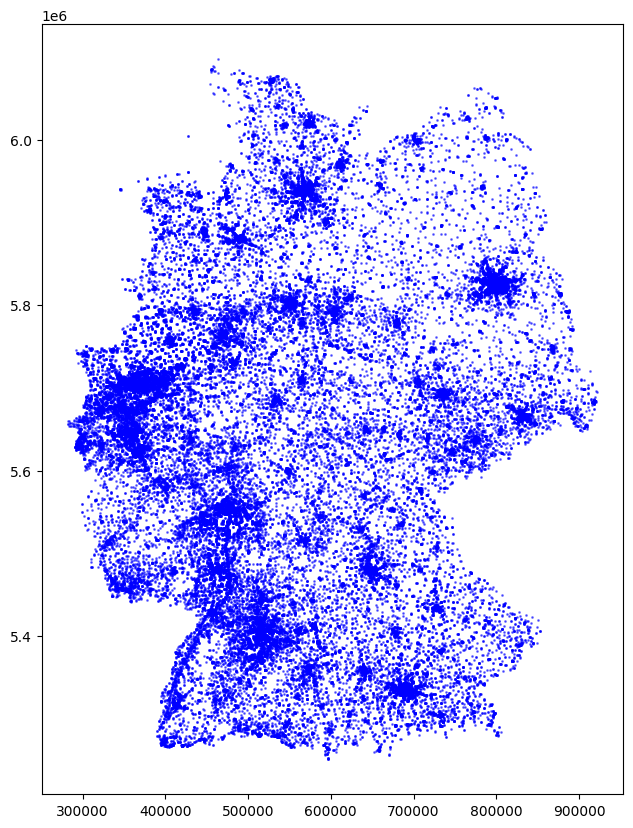

In [50]:
schools_gdf_25832=schools_gdf.to_crs(25832)

## plot all as points
schools_gdf_25832.centroid.plot(figsize=(10, 10), markersize=1, color='blue', alpha=0.5)

In [51]:
# buffer all schools by 50m and set right crs
schools_gdf_25832_buffer=schools_gdf_25832.copy()
schools_gdf_25832_buffer["geometry"]=schools_gdf_25832.buffer(50)

In [52]:
#set right crs 
accidents_25832=accidents.to_crs(25832)

In [53]:
# Ensure both datasets have spatial indexes
accidents_25832.sindex
schools_gdf_25832_buffer.sindex

# Faster alternative using a spatial join (used to clip here)
accidents_clipped = gpd.sjoin(
    accidents_25832, schools_gdf_25832_buffer, how="inner", predicate="intersects"
)#.drop(columns=["index_right","year"])  # Remove unnecessary index column (year is from network)

#accidents_clipped

In [54]:
# # as accident e.g. in crossings can be counted multiple times, we need to drop duplicates
# accidents_clipped = accidents_clipped[~accidents_clipped.index.duplicated(keep='first')]


In [57]:
#there is osm_way_id and osm_id, i wnat a sigle "id": if osm_way_id then id=way/{osm_way_id} if osm_id then id=node/{osm_id} can you do taht? 

In [58]:
# accidents_clipped["id"] = accidents_clipped.apply(
#     lambda row: f"way/{int(row.osm_way_id)}" if pd.notnull(row.osm_way_id) else (
#         f"node/{int(row.osm_id)}" if pd.notnull(row.osm_id) else None
#     ),
#     axis=1
# )

In [61]:
## filter accidents only since 2020 so all the same for germany
accidents_clipped=accidents_clipped[accidents_clipped.UJAHR.isin([2020,2021,2022,2023])]
accidents_clipped

,OBJECTID,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,...,PLST,geometry,index_right,osm_id,name,amenity,isced_level,source_layer,osm_way_id,oid
675476,10,12,0,54,0,2020,1,14,7,3,...,NaN,POINT (777002.181 5813905.675),19757,None,Kita Zauberstein,kindergarten,None,multipolygons,536913543,way/536913543
675580,114,12,0,61,316,2020,1,18,5,3,...,NaN,POINT (835211.456 5766402.286),16377,None,2. Grundschule,school,None,multipolygons,59661782,way/59661782
675592,126,12,0,65,332,2020,1,13,2,3,...,NaN,POINT (782512.79 5845324.205),20743,None,Kita Kinderland,kindergarten,None,multipolygons,203726639,way/203726639
675592,126,12,0,65,332,2020,1,13,2,3,...,NaN,POINT (782512.79 5845324.205),20740,None,None,school,None,multipolygons,203726635,way/203726635
675595,129,12,0,60,181,2020,1,6,6,2,...,NaN,POINT (807598.004 5840797.151),17204,None,Kinderhaus Fantasia Hort,kindergarten,None,multipolygons,286250828,way/286250828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677738,268960,16,0,53,0,2023,6,17,5,3,...,2.0,POINT (680972.991 5641611.442),11537,None,"Staatliche Grundschule ""Friedrich Schiller""",school,None,multipolygons,330656170,way/330656170
1677738,268960,16,0,53,0,2023,6,17,5,3,...,2.0,POINT (680972.991 5641611.442),11536,18632814,Kindergarten Pusteblume,kindergarten,None,multipolygons,None,node/18632814
1677789,269011,16,0,68,48,2023,9,19,5,3,...,2.0,POINT (649878.834 5663505.783),11303,None,Regenbogen,kindergarten,None,multipolygons,1374048521,way/1374048521
1677791,269013,16,0,70,4,2023,9,14,5,3,...,2.0,POINT (636861.717 5633569.553),10918,6772934426,St. Elisabeth,kindergarten,None,points,None,node/6772934426


In [65]:
accidents_clipped.columns

Index(['OBJECTID', 'ULAND', 'UREGBEZ', 'UKREIS', 'UGEMEINDE', 'UJAHR',
       'UMONAT', 'USTUNDE', 'UWOCHENTAG', 'UKATEGORIE', 'UART', 'UTYP1',
       'IstRad', 'IstPKW', 'IstFuss', 'IstKrad', 'IstSonstig', 'LICHT',
       'USTRZUSTAND', 'IstGkfz', 'PLST', 'geometry', 'index_right', 'osm_id',
       'name', 'amenity', 'isced_level', 'source_layer', 'osm_way_id', 'oid'],
      dtype='object')

In [62]:
accidents_clipped.oid.value_counts()

oid
way/385125919     45
way/129645989     40
way/368804405     40
way/159674547     39
way/38811140      38
                  ..
way/26253767       1
way/1050399928     1
way/308446745      1
way/79971149       1
way/458202986      1
Name: count, Length: 23415, dtype: int64

In [69]:
# Count total appearances of each oid
total_counts = accidents_clipped.oid.value_counts().rename("total_count")

# Count appearances where IstRad == 1
bike_counts = accidents_clipped[accidents_clipped.IstRad == 1].oid.value_counts().rename("bike_count")

# Count appearances where IstFuss == 1
ped_counts = accidents_clipped[accidents_clipped.IstFuss == 1].oid.value_counts().rename("ped_count")

# Count appearances where IstRad or IstFuss == 1
biped_counts = accidents_clipped[(accidents_clipped.IstRad == 1) | (accidents_clipped.IstFuss == 1)].oid.value_counts().rename("biped_counts")

# Combine into a DataFrame
oid_counts_df = pd.concat([total_counts, biped_counts, bike_counts, ped_counts], axis=1).fillna(0).astype(int).reset_index()
oid_counts_df = oid_counts_df.rename(columns={"index": "oid"})

oid_counts_df

,oid,total_count,biped_counts,bike_count,ped_count
0,way/385125919,45,34,31,3
1,way/129645989,40,39,38,1
2,way/368804405,40,30,30,0
3,way/159674547,39,24,20,7
4,way/38811140,38,12,12,1
...,...,...,...,...,...
23410,way/26253767,1,1,1,0
23411,way/1050399928,1,1,1,0
23412,way/308446745,1,1,1,0
23413,way/79971149,1,1,1,0


In [74]:
oid_counts_with_school = pd.merge( schools_gdf_25832_buffer, oid_counts_df, on="oid", how="left")
oid_counts_with_school

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,oid,total_count,biped_counts,bike_count,ped_count
0,1938163084,None,kindergarten,None,points,None,"POLYGON ((849063.271 5391604.269, 849063.03 53...",node/1938163084,NaN,NaN,NaN,NaN
1,None,None,school,None,multipolygons,192729055,"POLYGON ((843949.875 5391144.677, 843954.026 5...",way/192729055,NaN,NaN,NaN,NaN
2,None,None,school,None,multipolygons,192729054,"POLYGON ((843856.493 5391101.869, 843855.982 5...",way/192729054,NaN,NaN,NaN,NaN
3,None,Gymnasium Untergriesbach,school,None,multipolygons,192729051,"POLYGON ((843973.968 5391037.795, 843968.095 5...",way/192729051,NaN,NaN,NaN,NaN
4,None,None,school,None,multipolygons,192729052,"POLYGON ((843908.622 5391127.036, 843916.17 53...",way/192729052,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
81200,None,Kita Altforweiler,kindergarten,None,multipolygons,161591153,"POLYGON ((332852.395 5460729.73, 332852.154 54...",way/161591153,NaN,NaN,NaN,NaN
81201,None,Grundschule,school,None,multipolygons,252719088,"POLYGON ((333072.416 5460842.494, 333083.668 5...",way/252719088,NaN,NaN,NaN,NaN
81202,None,Kita,kindergarten,None,multipolygons,1250395881,"POLYGON ((332607.748 5458057.851, 332609.858 5...",way/1250395881,NaN,NaN,NaN,NaN
81203,None,Grundschule St. Oranna,school,None,multipolygons,238048642,"POLYGON ((331871.067 5459151.533, 331881.843 5...",way/238048642,NaN,NaN,NaN,NaN


In [91]:
oid_counts_with_school=oid_counts_with_school[oid_counts_with_school.biped_counts>2]

In [92]:
## check top10
oid_counts_with_school.sort_values("total_count", ascending=False)[:10].explore(tiles="CartoDB positron")

In [93]:
oid_counts_with_school[["total_count", "biped_counts", "bike_count", "ped_count"]] = (
    oid_counts_with_school[["total_count", "biped_counts", "bike_count", "ped_count"]].fillna(0).astype(int)
)
oid_counts_with_school

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,oid,total_count,biped_counts,bike_count,ped_count
13927,None,Sankt-Benno-Gymnasium,school,None,multipolygons,385125919,"POLYGON ((13.75577 51.0503, 13.75576 51.05031,...",way/385125919,45,34,31,3
746,None,Ludwig-Thoma-Gymnasium,school,None,multipolygons,129645989,"POLYGON ((12.34718 47.85697, 12.34717 47.85699...",way/129645989,40,39,38,1
2217,None,Ignaz-Günther-Gymnasium,school,3,multipolygons,368804405,"POLYGON ((12.11971 47.85882, 12.12051 47.85879...",way/368804405,40,30,30,0
4664,None,Schule an der Fürstenrieder Straße,school,None,multipolygons,159674547,"POLYGON ((11.50347 48.13881, 11.50346 48.13876...",way/159674547,39,24,20,7
67071,None,Max-Planck-Schule,school,2;3,multipolygons,38811140,"POLYGON ((8.42383 49.9904, 8.42405 49.99082, 8...",way/38811140,38,12,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...
15673,None,None,school,None,multipolygons,198763515,"POLYGON ((14.00096 51.51756, 14.00142 51.51759...",way/198763515,3,3,3,0
26699,None,Grundschule Wittekind,school,None,multipolygons,1303109098,"POLYGON ((11.95786 51.50113, 11.95833 51.5012,...",way/1303109098,3,3,2,1
51980,None,Berufsbildungszentrum Neuss-Weingartstraße,school,None,multipolygons,213841208,"POLYGON ((6.69376 51.18956, 6.69337 51.18997, ...",way/213841208,3,3,3,1
52039,4782910747,Hoteli Grosstagespflege,kindergarten,None,points,None,"POLYGON ((6.76149 51.20832, 6.76149 51.20828, ...",node/4782910747,3,3,3,0


In [94]:
oid_counts_with_school=oid_counts_with_school.to_crs(4326).copy()
oid_counts_with_school.to_file("scenario2_accidents_close2schools_polys.fgb", driver="FlatGeobuf")



In [95]:
oid_counts_with_school_centroids = oid_counts_with_school.copy()
oid_counts_with_school_centroids = oid_counts_with_school_centroids.to_crs(25832)
oid_counts_with_school_centroids["geometry"] = oid_counts_with_school_centroids.geometry.centroid
oid_counts_with_school_centroids=oid_counts_with_school_centroids.to_crs(4326)

oid_counts_with_school_centroids

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,oid,total_count,biped_counts,bike_count,ped_count
13927,None,Sankt-Benno-Gymnasium,school,None,multipolygons,385125919,POINT (13.75716 51.05122),way/385125919,45,34,31,3
746,None,Ludwig-Thoma-Gymnasium,school,None,multipolygons,129645989,POINT (12.34863 47.85736),way/129645989,40,39,38,1
2217,None,Ignaz-Günther-Gymnasium,school,3,multipolygons,368804405,POINT (12.12104 47.85788),way/368804405,40,30,30,0
4664,None,Schule an der Fürstenrieder Straße,school,None,multipolygons,159674547,POINT (11.50221 48.13909),way/159674547,39,24,20,7
67071,None,Max-Planck-Schule,school,2;3,multipolygons,38811140,POINT (8.42532 49.98971),way/38811140,38,12,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...
15673,None,None,school,None,multipolygons,198763515,POINT (14.00172 51.51672),way/198763515,3,3,3,0
26699,None,Grundschule Wittekind,school,None,multipolygons,1303109098,POINT (11.95867 51.50048),way/1303109098,3,3,2,1
51980,None,Berufsbildungszentrum Neuss-Weingartstraße,school,None,multipolygons,213841208,POINT (6.69512 51.18984),way/213841208,3,3,3,1
52039,4782910747,Hoteli Grosstagespflege,kindergarten,None,points,None,POINT (6.76077 51.20831),node/4782910747,3,3,3,0


In [96]:

oid_counts_with_school_centroids.to_file("scenario2_accidents_close2schools_points.fgb", driver="FlatGeobuf")



In [97]:
def fgb_to_pmtiles_dual_layer(points_fgb, polys_fgb, output_pmtiles):
    import subprocess
    from pathlib import Path

    tmp_points = "tmp_points.pmtiles"
    tmp_polys = "tmp_polys.pmtiles"

    subprocess.run([
        "tippecanoe", "-o", tmp_points,
        "--layer=scenario2-points",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
        str(Path(points_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tippecanoe", "-o", tmp_polys,
        "--layer=scenario2-polys",
        "--minimum-zoom=14", "--maximum-zoom=15",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        str(Path(polys_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tile-join", "--force", "-o", str(Path(output_pmtiles).resolve()),
        tmp_points, tmp_polys
    ], check=True)

    print("✅ Combined PMTiles created")


In [98]:
fgb_to_pmtiles_dual_layer(
    points_fgb="scenario2_accidents_close2schools_points.fgb",
    polys_fgb="scenario2_accidents_close2schools_polys.fgb",
    output_pmtiles="scenario2_accidents_close2schools.pmtiles"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
3726 features, 233953 bytes of geometry and attributes, 196457 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8653/5291  
detected indexed FlatGeobuf: assigning feature IDs by sequence
3726 features, 1280250 bytes of geometry and attributes, 196457 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  15/16952/10886  


✅ Combined PMTiles created
